A lender wants to approve good borrowers and reject risky ones. What does a wrong decision cost in each direction? This alone makes it look more professional than most student projects.

# DATA

In [111]:
import pandas as pd

In [112]:
df = pd.read_csv('accepted_2007_to_2018Q4.csv')

/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3701891125.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('accepted_2007_to_2018Q4.csv')


In [113]:
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [115]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.0000,40000.00
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.00,20000.0000,40000.00
funded_amnt_inv,2260668.0,15023.437745,9192.331679,0.00,8000.00,12800.00,20000.0000,40000.00
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.9900,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.0,11636.883942,7625.988281,55.73,5627.00,10028.39,16151.8900,40306.41
hardship_last_payment_amount,10917.0,193.994321,198.629496,0.01,44.44,133.16,284.1900,1407.86
settlement_amount,34246.0,5010.664267,3693.122590,44.21,2208.00,4146.11,6850.1725,33601.00
settlement_percentage,34246.0,47.780365,7.311822,0.20,45.00,45.00,50.0000,521.35


In [116]:
#missing values
missing = df.isnull().mean().sort_values(ascending=False)*100
print(missing.head(40))

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_end_date                              99.517097
hardship_start_date                            99.517097
hardship_type                                  99.517097
hardship_reason                                99.517097
hardship_status                                99.517097
deferral_term                                  99.517097
hardship_last_payment_amount                   99.517097
hardship_payoff_balance_amount                 99.517097
hardship_loan_status                           99.517097
hardship_dpd                                   99.517097
hardship_length                                99.517097
payment_plan_start_date                        99.517097
hardship_amount                                99.517097
settlement_term                                98.485160
debt_settlement_flag_date                      98.485160
settlement_status              

In [117]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [118]:
#define the target from loan_status

#1 = changed off, default, does not mean the credit policy: charged off
#0 = fully paid, does not mean the credit policy: fully paid
#and drop current, in grade period and late ones

good = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']
bad = ['Charged Off', 'Does not meet the credit policy. Status:Charged Off','Default']

df = df[df['loan_status'].isin(good+bad)].copy()
df['target'] = df['loan_status'].isin(bad).astype(int) #if bad 1, if good 0

print(df['target'].value_counts(normalize=True))


target
0    0.800193
1    0.199807
Name: proportion, dtype: float64


Decide at the moment someone applied whether to give them a loan. So it is adviced to only use information the lender has at the moment, meaning that do not consider loans that are currently in the process since we won't know if they will default, and also come columns store data that was colected after the loan was isseud. If we do not remove them, the prediction would be basically guessing or with overfit. 

In [119]:
#drop unnecessary columns and values

leak_prefix = ['hardshhip_','settlement_','debt_settlement_']
leak_columns = ['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'out_prncp', 'out_prncp_inv', 'last_fico_range_high', 'last_fico_range_low', 'last_credit_pull_d','funded_amnt', 'funded_amnt_inv', 'deferral_term','payment_plan_start_data','origid_projected_additional_accrued_interest','paymnt_plan']
other_cols = ['id','member_id','url','desc','title','emp_title','loan_status']

drop = leak_columns+other_cols+[c for c in df.columns if c.startswith(tuple(leak_prefix))]
df = df.drop(columns = [c for c in drop if c in df.columns])
missing = df.isnull().mean()
df=df.drop(columns = missing[missing>0.5].index) #remove lines with more than 50% missing values
print(df.shape)

(1348099, 72)


In [120]:
df.head(20)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,target
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,0
5,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,0
6,20000.0,36 months,9.17,637.58,B,B2,10+ years,MORTGAGE,180000.0,Not Verified,...,100.0,0.0,0.0,388852.0,116762.0,31500.0,46452.0,N,Cash,0
7,20000.0,36 months,8.49,631.26,B,B1,10+ years,MORTGAGE,85000.0,Not Verified,...,0.0,0.0,0.0,193390.0,27937.0,14500.0,36144.0,N,Cash,0
8,10000.0,36 months,6.49,306.45,A,A2,6 years,RENT,85000.0,Not Verified,...,28.6,1.0,0.0,61099.0,27957.0,16400.0,30799.0,N,Cash,0
9,8000.0,36 months,11.48,263.74,B,B5,10+ years,MORTGAGE,42000.0,Not Verified,...,33.3,0.0,0.0,256513.0,113782.0,17000.0,135513.0,N,Cash,0
12,1400.0,36 months,12.88,47.10,C,C2,3 years,MORTGAGE,64000.0,Not Verified,...,75.0,0.0,0.0,372109.0,75258.0,34500.0,55501.0,N,Cash,0


In [121]:
#verify datatype

text_cols = df.select_dtypes(include = 'object').columns.tolist()
print(text_cols)
df[text_cols].tail()


['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method']


,term,grade,sub_grade,emp_length,home_ownership,verification_status,issue_d,pymnt_plan,purpose,zip_code,addr_state,earliest_cr_line,initial_list_status,application_type,hardship_flag,disbursement_method
2260688,60 months,B,B2,5 years,OWN,Not Verified,Oct-2016,n,home_improvement,775xx,TX,Jul-2004,f,Individual,N,Cash
2260690,60 months,C,C3,9 years,MORTGAGE,Not Verified,Oct-2016,n,debt_consolidation,900xx,CA,Mar-2002,f,Individual,N,Cash
2260691,60 months,C,C4,3 years,MORTGAGE,Source Verified,Oct-2016,n,home_improvement,863xx,AZ,Jun-2011,f,Individual,N,Cash
2260692,60 months,C,C1,10+ years,RENT,Not Verified,Oct-2016,n,medical,284xx,NC,Aug-1997,f,Individual,N,Cash
2260697,60 months,C,C4,6 years,RENT,Not Verified,Oct-2016,n,debt_consolidation,334xx,FL,Jul-1999,f,Individual,N,Cash


In [122]:
df['term']=df['term'].str.extract(r"(\d+)").astype(int) #extract numerical values/remove 'months'accepted_2007_to_2018Q4.csv

df['emp_length']=df['emp_length'].str.extract(r"(\d+)").astype(float) #extract numerical values/remove 'years'

df['issue_d'] = pd.to_datetime(df['issue_d'],format = '%b-%Y')

df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'],format = '%b-%Y')

#the date when the credit was opened is not that useful, so calculate how long they had the credit 
df['credit_history_years'] = (df['issue_d']-df['earliest_cr_line']).dt.days/365
df = df.drop(columns = 'earliest_cr_line')

df = df.drop(columns = ['zip_code', 'hardship_flag','pymnt_plan','disbursement_method']) 


In [123]:
df['emp_length']=df['emp_length'].astype('Int64')

In [124]:
new_text = ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']
df[new_text].head()

,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,C,C4,MORTGAGE,Not Verified,debt_consolidation,PA,w,Individual
1,C,C1,MORTGAGE,Not Verified,small_business,SD,w,Individual
2,B,B4,MORTGAGE,Not Verified,home_improvement,IL,w,Joint App
4,F,F1,MORTGAGE,Source Verified,major_purchase,PA,w,Individual
5,C,C3,RENT,Source Verified,debt_consolidation,GA,w,Individual


In [125]:
df[['term','emp_length','issue_d','credit_history_years']].head()

,term,emp_length,issue_d,credit_history_years
0,36,10,2015-12-01,12.342466
1,36,10,2015-12-01,16.010959
2,60,10,2015-12-01,15.342466
4,60,3,2015-12-01,17.512329
5,36,4,2015-12-01,28.186301


In [126]:
#save clean dataset
df.to_parquet('loan_clean.parquet')

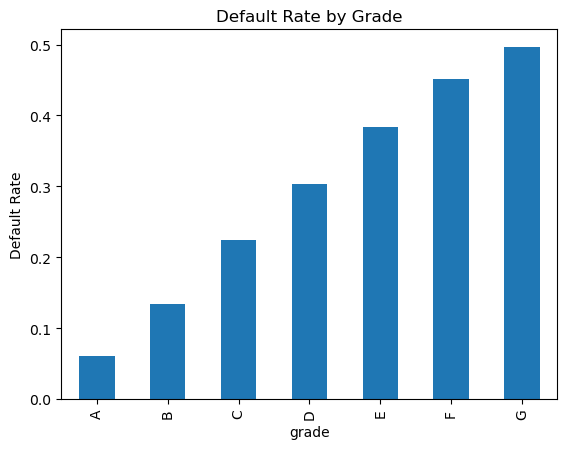

In [127]:
import matplotlib.pyplot as plt

df.groupby('grade')['target'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.title('Default Rate by Grade')
plt.show()

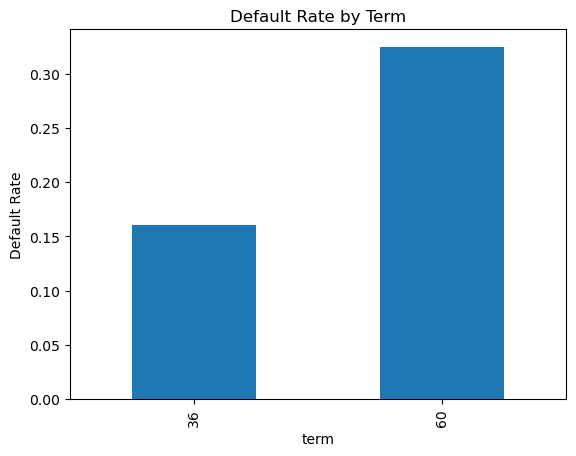

In [128]:
df.groupby('term')['target'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.title('Default Rate by Term')
plt.show()

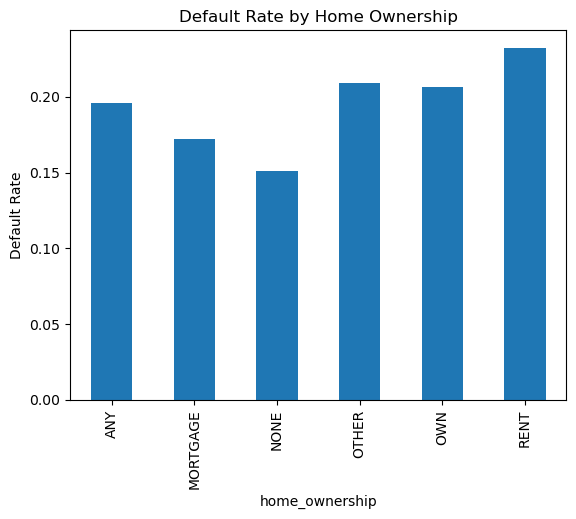

In [129]:
df.groupby('home_ownership')['target'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.title('Default Rate by Home Ownership')
plt.show()

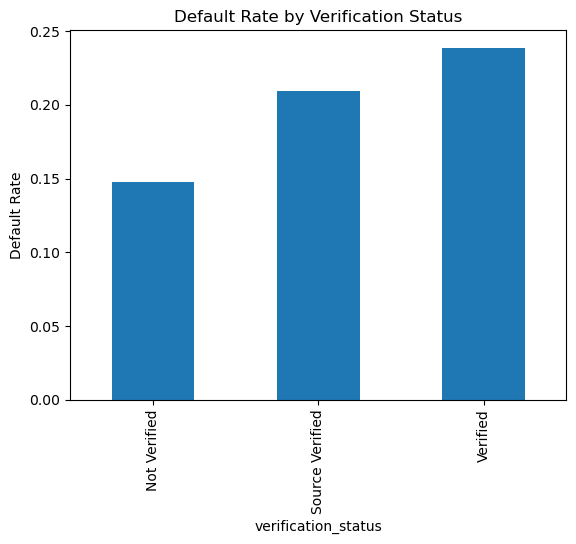

In [130]:
df.groupby('verification_status')['target'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.title('Default Rate by Verification Status')
plt.show()

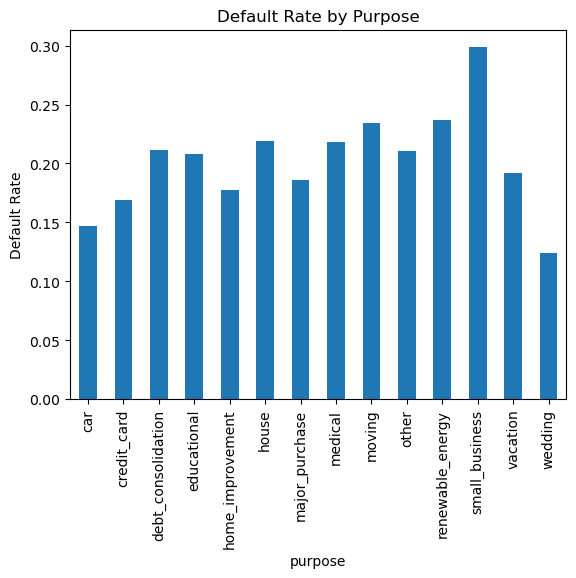

In [131]:
df.groupby('purpose')['target'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.title('Default Rate by Purpose')
plt.show()

In [132]:
# see how variables differ for defaulted and non-defaulted loans

df.groupby('target')[['int_rate','dti','annual_inc','fico_range_low','loan_amnt','credit_history_years']].median() 

,int_rate,dti,annual_inc,fico_range_low,loan_amnt,credit_history_years
target,,,,,,
0,12.29,17.10,65000.0,690.0,12000.0,14.849315
1,15.05,19.75,60000.0,680.0,14300.0,14.254795


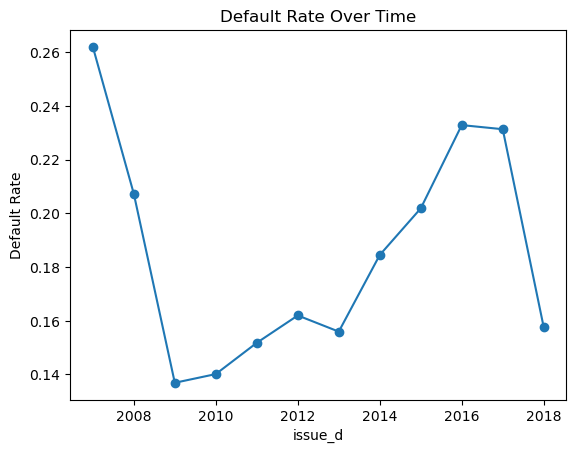

issue_d
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64

In [133]:
#default rate over time

df.groupby(df['issue_d'].dt.year)['target'].mean().plot(marker='o')
plt.ylabel('Default Rate')
plt.title('Default Rate Over Time')
plt.show()

df['issue_d'].dt.year.value_counts().sort_index()

In [134]:
df[['annual_inc','dti','revol_util']].describe(percentiles=[0.01,0.99]).T

,count,mean,std,min,1%,50%,99%,max
annual_inc,1348095.0,76237.743295,69922.741975,0.0,18000.00,65000.00,251000.00,10999200.0
dti,1347725.0,18.274253,11.155495,-1.0,1.77,17.61,38.47,999.0
revol_util,1347202.0,51.812003,24.529794,0.0,1.10,52.20,98.20,892.3


In [135]:
print(df[['annual_inc','dti','revol_util']].describe(percentiles=[0.01,0.99]).count())

#drop this values

df = df.drop(df[(df['dti']<0)|(df['dti']>=999)].index)

annual_inc    8
dti           8
revol_util    8
dtype: int64


In [136]:
corr = df.select_dtypes('number').corr()
high = corr.abs().unstack().sort_values(ascending=False)
print(high[(high<1) & (high>0.8)].drop_duplicates())

fico_range_low              fico_range_high         1.000000
num_sats                    open_acc                0.998729
num_actv_rev_tl             num_rev_tl_bal_gt_0     0.982027
tot_hi_cred_lim             tot_cur_bal             0.972804
installment                 loan_amnt               0.953434
credit_history_years        mo_sin_old_rev_tl_op    0.917908
total_il_high_credit_limit  total_bal_ex_mort       0.872656
bc_util                     revol_util              0.855026
                            percent_bc_gt_75        0.844702
bc_open_to_buy              total_bc_limit          0.838806
num_bc_tl                   num_rev_accts           0.838450
tot_cur_bal                 avg_cur_bal             0.835041
open_acc                    num_op_rev_tl           0.831025
num_op_rev_tl               num_sats                0.830180
num_actv_bc_tl              num_bc_sats             0.829311
revol_bal                   total_rev_hi_lim        0.810241
num_actv_rev_tl         

In [137]:
print(df['bc_util'].isnull().sum())
print(df['revol_util'].isnull().sum())

64663
897


In [138]:
finish = df.groupby([df['term'], df['issue_d'].dt.year]).size().unstack()
print(finish)

issue_d   2007    2008    2009    2010     2011     2012      2013      2014  \
term                                                                           
36       603.0  2393.0  5281.0  9156.0  14101.0  43470.0  100422.0  162570.0   
60         NaN     NaN     NaN  3381.0   7620.0   9897.0   34382.0   60533.0   

issue_d      2015      2016      2017     2018  
term                                            
36       283025.0  232355.0  128542.0  41268.0  
60        92520.0   60743.0   40753.0  15044.0  


In [139]:
rateperyear = df.groupby([df['term'], df['issue_d'].dt.year])['target'].mean().unstack()
print(rateperyear)

issue_d      2007      2008      2009      2010      2011      2012      2013  \
term                                                                            
36       0.262023  0.207271  0.136906  0.109218  0.106305  0.135795  0.123260   
60            NaN       NaN       NaN  0.223898  0.235958  0.276953  0.251469   

issue_d      2014      2015      2016      2017      2018  
term                                                       
36       0.137264  0.148863  0.198476  0.200184  0.132476  
60       0.311351  0.363943  0.364338  0.329620  0.226403  


In [140]:
df = df.drop(df[(df['term']==36) & (df['issue_d'].dt.year>2015)].index)
df = df.drop(df[(df['term']==60) & (df['issue_d'].dt.year>2013)].index)

In [141]:
finish_new = df.groupby([df['term'], df['issue_d'].dt.year]).size().unstack()
print(finish_new)

issue_d   2007    2008    2009    2010     2011     2012      2013      2014  \
term                                                                           
36       603.0  2393.0  5281.0  9156.0  14101.0  43470.0  100422.0  162570.0   
60         NaN     NaN     NaN  3381.0   7620.0   9897.0   34382.0       NaN   

issue_d      2015  
term               
36       283025.0  
60            NaN  


In [142]:
drop_columns = ['bc_util','installment','mo_sin_old_rev_tl_op','tot_hi_cred_lim','num_sats','num_op_rev_tl', 'fico_range_low','tot_cur_bal','num_bc_sats','num_rev_tl_bal_gt_0']
df = df.drop(columns = [c for c in drop_columns if c in df.columns])

In [143]:
corr = df.select_dtypes('number').corr()
high = corr.abs().unstack().sort_values(ascending=False)
print(high[(high<1) & (high>0.8)].drop_duplicates())

total_il_high_credit_limit  total_bal_ex_mort    0.861153
bc_open_to_buy              total_bc_limit       0.840971
num_rev_accts               num_bc_tl            0.839763
revol_bal                   total_rev_hi_lim     0.814301
dtype: float64


# Preprocessing for logistic regression

In [144]:
train = df[~(((df['issue_d'].dt.year==2013) & (df['term']==60) )| ((df['issue_d'].dt.year==2015) & (df['term']==36)))].copy()
test = df[((df['issue_d'].dt.year==2013) & (df['term']==60) )| ((df['issue_d'].dt.year==2015) & (df['term']==36))].copy()

In [145]:
print(train['target'].mean())
print(test['target'].mean())
print(train.shape)
print(test.shape)

0.1386704709468534
0.15997756823258466
(358894, 58)
(317407, 58)


Binning and Weight of Evidence:

Binning means grouping a variable's into buckets. 

WoE gives each bucket a single number that says how safe or risky it is
WoE = ln(share of all good loans in this bin / share of all bad loans in this bin)
WoE>0: more good loans; WoE<0: more bad loans; WoE=0: approx. avg.

Information Value summarizes how useful the whole variable is
IV = sum over bins of (% good- % bad)*WoE
Commonly, below 0.02 is useless; 0.02-0.1 weak; 0.1-0.3 medium; 0.3-0.5 strong; above 0.5 is suspicious (potential overfit)

In [146]:
bad_per_grade = train.groupby('grade')['target'].sum()
good_per_grade = train.groupby('grade')['target'].count() - bad_per_grade
print(bad_per_grade)
print(good_per_grade)

grade
A     4079
B    13596
C    15039
D    10552
E     4524
F     1628
G      350
Name: target, dtype: int64
grade
A     69395
B    111073
C     74311
D     37802
E     12352
F      3576
G       617
Name: target, dtype: int64


In [147]:
sum_of_all_good = train[train['target']==0].groupby('grade')['target'].count()
sum_of_all_bad = train[train['target']==1].groupby('grade')['target'].count()
sum_good = sum_of_all_good.sum()
sum_bad = sum_of_all_bad.sum()


good_share = good_per_grade/sum_good
bad_share = bad_per_grade/sum_bad
print(bad_share)
print(good_share)

grade
A    0.081960
B    0.273188
C    0.302182
D    0.212024
E    0.090902
F    0.032712
G    0.007033
Name: target, dtype: float64
grade
A    0.224488
B    0.359313
C    0.240391
D    0.122287
E    0.039958
F    0.011568
G    0.001996
Name: target, dtype: float64


In [148]:
import numpy as np
WoE = np.log(good_share/bad_share)
vi = ((good_share-bad_share)*WoE).sum()
print(WoE)
print(vi)

grade
A    1.007586
B    0.274035
C   -0.228765
D   -0.550330
E   -0.821955
F   -1.039484
G   -1.259441
Name: target, dtype: float64
0.30092642196488867


From the above we can assume that the worse the grade, the riskier the borrower

In [149]:
#create a reusable function for WoE and IV calculation
def woe_vi(train_data, grade_column,target_column='target'):
    data = train_data.copy()
    if pd.api.types.is_numeric_dtype(data[grade_column]) and data[grade_column].nunique()>10:
        #bin it first
        data[grade_column] = pd.qcut(data[grade_column],q=10, duplicates = 'drop')
    sum_of_all_good = data[data[target_column]==0].groupby(grade_column,dropna=False)[target_column].count()
    sum_of_all_bad = data[data[target_column]==1].groupby(grade_column,dropna=False)[target_column].count()
    sum_good = sum_of_all_good.sum()
    sum_bad = sum_of_all_bad.sum()
    good_share = sum_of_all_good/sum_good
    bad_share = sum_of_all_bad/sum_bad
    WoE = np.log(good_share/bad_share)
    vi = ((good_share-bad_share)*WoE).sum()
    return WoE, vi

In [150]:
print(woe_vi(train, 'fico_range_high','target'))

(fico_range_high
(613.999, 669.0]   -0.363303
(669.0, 674.0]     -0.299762
(674.0, 679.0]     -0.199811
(679.0, 684.0]     -0.184099
(684.0, 694.0]     -0.067512
(694.0, 699.0]      0.010698
(699.0, 709.0]      0.129944
(709.0, 724.0]      0.311004
(724.0, 744.0]      0.444159
(744.0, 850.0]      0.849798
Name: target, dtype: float64, 0.1162687156467987)


/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_of_all_good = data[data[target_column]==0].groupby(grade_column,dropna=False)[target_column].count()
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_of_all_bad = data[data[target_column]==1].groupby(grade_column,dropna=False)[target_column].count()


In [151]:
dict1={}
for i in train.columns[~train.columns.isin(['target','issue_d'])]:
    woe,iv = woe_vi(train, i, 'target')
    dict1[i] = iv
iv = pd.Series(dict1).sort_values(ascending=True)
print(iv)

/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_of_all_good = data[data[target_column]==0].groupby(grade_column,dropna=False)[target_column].count()
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_of_all_bad = data[data[target_column]==1].groupby(grade_column,dropna=False)[target_column].count()
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:7: FutureWarning: The default of observed=False is deprecated and will b

application_type              0.000000
policy_code                   0.000000
delinq_amnt                   0.000008
tax_liens                     0.000027
acc_now_delinq                0.000050
pub_rec                       0.000220
chargeoff_within_12_mths      0.000238
open_acc                      0.000296
collections_12_mths_ex_med    0.000369
delinq_2yrs                   0.000779
loan_amnt                     0.002316
initial_list_status           0.003067
pub_rec_bankruptcies          0.003819
num_tl_90g_dpd_24m            0.005906
num_tl_30dpd                  0.006138
num_tl_120dpd_2m              0.006184
pct_tl_nvr_dlq                0.006389
num_accts_ever_120_pd         0.006464
tot_coll_amt                  0.006473
num_rev_accts                 0.007117
total_acc                     0.007701
total_bal_ex_mort             0.009075
revol_bal                     0.009387
num_actv_bc_tl                0.009547
num_bc_tl                     0.009859
num_il_tl                

/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_of_all_good = data[data[target_column]==0].groupby(grade_column,dropna=False)[target_column].count()
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3737311187.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_of_all_bad = data[data[target_column]==1].groupby(grade_column,dropna=False)[target_column].count()


As mentioned above, IV<0.02 are nor relevant, so remove all of them from dataset. 

In [152]:
train = train.drop(columns = iv[iv<0.02].index)
test = test.drop(columns = iv[iv<0.02].index)

In [153]:
print(train.shape)
print(test.shape)

(358894, 26)
(317407, 26)


In [154]:
for i in ['total_il_high_credit_limit','total_bal_ex_mort','bc_open_to_buy','total_bc_limit','num_rev_accts','num_bc_tl','revol_bal','total_rev_hi_lim']: 
    if i in iv[iv>0.02]:
        print(f"{i}:{iv[i]}")
#print iv for values that still have high correlation, and remove the ones with lower iv, and the ones which where not yet removed from dataset before

bc_open_to_buy:0.06840675753389651
total_bc_limit:0.057448159521633915
total_rev_hi_lim:0.04724632021345709


In [155]:
train = train.drop(columns = ['total_bc_limit'])
test = test.drop(columns = ['total_bc_limit'])
print(train.shape)
print(test.shape)

(358894, 25)
(317407, 25)


In [156]:
#create a reusable function for WoE and IV calculation
def fit_woe(train_data, grade_column,target_column='target'):
    data = train_data.copy()
    if pd.api.types.is_numeric_dtype(data[grade_column]) and data[grade_column].nunique()>10:
        #bin it first
        bins, edges = pd.qcut(data[grade_column],q=10, duplicates = 'drop', retbins = True)
        edges[0], edges[-1] = -np.inf, np.inf
        bins = pd.cut(train_data[grade_column], bins = edges) #rebin with 'open' edges
        data['bins'] = bins
    else:
        edges = None
        data['bins'] = data[grade_column]
    sum_of_all_good = data[data[target_column]==0].groupby(data['bins'],dropna=False, observed = False)[target_column].count()
    sum_of_all_bad = data[data[target_column]==1].groupby(data['bins'],dropna=False, observed = False)[target_column].count()
    sum_good = sum_of_all_good.sum()
    sum_bad = sum_of_all_bad.sum()
    good_share = sum_of_all_good/sum_good
    bad_share = sum_of_all_bad/sum_bad
    WoE = np.log(good_share/bad_share)
    return WoE, edges
    

In [157]:
print(fit_woe(train, 'home_ownership','target'))

(bins
ANY              NaN
MORTGAGE    0.184170
NONE       -0.168149
OTHER      -0.494150
OWN        -0.046540
RENT       -0.167558
Name: target, dtype: float64, None)


In [158]:
def apply_woe(test_data, grade_column, woe, edges):
    if edges is not None:
        bins = pd.cut(test_data[grade_column], bins = edges) # uses given edegs to decide where the data goes
    else:
        bins = test_data[grade_column]
    new_woe = bins.map(woe).astype(float).fillna(0)
    return new_woe

In [159]:
woe, edges = fit_woe(train, 'home_ownership','target')
print(apply_woe(test, 'home_ownership',woe, edges))

0          0.184170
1          0.184170
5         -0.167558
6          0.184170
7          0.184170
             ...   
1888035   -0.167558
1888075    0.184170
1888289    0.184170
1888796    0.184170
1889206    0.184170
Name: home_ownership, Length: 317407, dtype: float64


In [160]:
train_woe = pd.DataFrame(index = train.index)
test_woe = pd.DataFrame(index = test.index)

for i in train.columns[~train.columns.isin(['target','issue_d'])]:
    woe,edges = fit_woe(train, i, 'target')
    train_woe[i] =apply_woe(train, i, woe, edges)
    test_woe[i] = apply_woe(test, i , woe, edges)

train_woe['target'] = train['target'].copy()
test_woe['target'] = test['target'].copy()

print(train_woe.shape)
print(test_woe.shape)

(358894, 24)
(317407, 24)


In [161]:
print(train_woe.isnull().sum().sum())
print(train_woe.nunique())

0
term                      2
int_rate                 10
grade                     7
sub_grade                35
home_ownership            6
annual_inc               11
purpose                  14
dti                      10
fico_range_high          10
inq_last_6mths            4
revol_util               11
total_rev_hi_lim         11
acc_open_past_24mths      9
avg_cur_bal              11
bc_open_to_buy           11
mo_sin_old_il_acct       11
mo_sin_rcnt_rev_tl_op    11
mo_sin_rcnt_tl           10
mort_acc                  6
mths_since_recent_bc     11
num_actv_rev_tl          10
num_tl_op_past_12m        6
percent_bc_gt_75          8
target                    2
dtype: int64


# Logistic regression

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

#model A: exlude its owm risk assessment, that is, grade, sub grade, int rate

X_train = train_woe.drop(columns=['target', 'grade','sub_grade','int_rate'])
y_train = train_woe['target']
X_test = test_woe.drop(columns=['target','grade','sub_grade','int_rate'])
y_test = test_woe['target']

logreg = LogisticRegression()

model = logreg.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:,1] #gives each borrower's predicted probability of default 

print(pred[:5])
AUC = roc_auc_score(y_test, pred)
gini = 2*AUC-1
print(gini)
pd.Series(model.coef_[0], index = X_train.columns).sort_values()

[0.11242532 0.16970416 0.12619163 0.12420133 0.04737549]
0.33948829819653836


term                    -0.991453
purpose                 -0.879901
fico_range_high         -0.781699
inq_last_6mths          -0.774401
annual_inc              -0.759666
acc_open_past_24mths    -0.606417
dti                     -0.589897
revol_util              -0.468730
mths_since_recent_bc    -0.433298
home_ownership          -0.380292
bc_open_to_buy          -0.338832
mo_sin_old_il_acct      -0.270013
num_tl_op_past_12m      -0.243922
avg_cur_bal             -0.222175
mo_sin_rcnt_tl          -0.156603
mort_acc                -0.087855
percent_bc_gt_75        -0.048478
num_actv_rev_tl          0.031533
total_rev_hi_lim         0.221158
mo_sin_rcnt_rev_tl_op    0.223225
dtype: float64

In [181]:
#remove values woth largest positive coef
#model A: exlude its owm risk assessment, that is, grade, sub grade, int rate

X_train_A = train_woe.drop(columns=['target', 'grade','sub_grade','int_rate','mo_sin_rcnt_rev_tl_op','total_rev_hi_lim','num_actv_rev_tl'])
y_train_A = train_woe['target']
X_test_A = test_woe.drop(columns=['target','grade','sub_grade','int_rate','mo_sin_rcnt_rev_tl_op','total_rev_hi_lim','num_actv_rev_tl'])
y_test_A = test_woe['target']

logreg = LogisticRegression()

model_A = logreg.fit(X_train_A, y_train)
pred_A = model_A.predict_proba(X_test_A)[:,1] #gives each borrower's predicted probability of default 

print(pred[:5])
AUC = roc_auc_score(y_test_A, pred)
gini = 2*AUC-1
print(gini)
series = pd.Series(model_A.coef_[0], index = X_train.columns).sort_values()

[0.13574694 0.16842048 0.14548414 0.08016271 0.05078798]
0.38457170554603515


ValueError: Length of values (17) does not match length of index (19)

In [164]:
#model B: including risk assessment (only sub grade to avoid multicolinearity)
X_train = train_woe.drop(columns=['target','grade','int_rate'])
y_train = train_woe['target']
X_test = test_woe.drop(columns=['target','grade','int_rate'])
y_test = test_woe['target']

logreg = LogisticRegression()

model = logreg.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:,1] #gives each borrower's predicted probability of default 

print(pred[:5])
AUC = roc_auc_score(y_test, pred)
gini = 2*AUC-1
print(gini)
pd.Series(model.coef_[0], index = X_train.columns).sort_values()

[0.13431175 0.16795054 0.15021454 0.08376243 0.05138168]
0.38483590997468253


annual_inc              -0.717497
sub_grade               -0.667027
acc_open_past_24mths    -0.563247
term                    -0.554909
purpose                 -0.494861
dti                     -0.494440
inq_last_6mths          -0.440476
mths_since_recent_bc    -0.368434
home_ownership          -0.344517
revol_util              -0.294420
fico_range_high         -0.209272
num_actv_rev_tl         -0.198595
avg_cur_bal             -0.140082
mo_sin_rcnt_tl          -0.135065
bc_open_to_buy          -0.126704
mo_sin_old_il_acct      -0.101593
num_tl_op_past_12m      -0.071037
mort_acc                -0.050424
percent_bc_gt_75         0.005873
total_rev_hi_lim         0.092946
mo_sin_rcnt_rev_tl_op    0.250628
dtype: float64

In [165]:
#rerun regressions without positive coed variables
#model B: including risk assessment (only sub grade to avoid multicolinearity)
X_train = train_woe.drop(columns=['target','grade','int_rate','mo_sin_rcnt_rev_tl_op','total_rev_hi_lim'])
y_train = train_woe['target']
X_test = test_woe.drop(columns=['target','grade','int_rate','mo_sin_rcnt_rev_tl_op','total_rev_hi_lim'])
y_test = test_woe['target']

logreg = LogisticRegression()

model = logreg.fit(X_train, y_train)
pred = model.predict_proba(X_test)[:,1] #gives each borrower's predicted probability of default 

print(pred[:5])
AUC = roc_auc_score(y_test, pred)
gini = 2*AUC-1
print(gini)
new_series = pd.Series(model.coef_[0], index = X_train.columns).sort_values()
print(new_series)

[0.13574694 0.16842048 0.14548414 0.08016271 0.05078798]
0.38457170554603515
annual_inc             -0.684829
sub_grade              -0.662205
term                   -0.558923
acc_open_past_24mths   -0.542271
dti                    -0.525704
purpose                -0.518307
inq_last_6mths         -0.442935
home_ownership         -0.327714
mths_since_recent_bc   -0.276738
revol_util             -0.250888
fico_range_high        -0.230559
num_actv_rev_tl        -0.180588
avg_cur_bal            -0.130801
bc_open_to_buy         -0.069654
mort_acc               -0.066057
mo_sin_old_il_acct     -0.064249
num_tl_op_past_12m     -0.058692
percent_bc_gt_75       -0.030904
mo_sin_rcnt_tl         -0.016994
dtype: float64


In [166]:
#create a credit score out of default probabilities
#from latest model A
scores = pd.DataFrame(pred_A, index = y_test_A.index)
scores['credit_score'] = scores[0]
pdo = 20
factor = pdo/np.log(2)
offset = 600-factor*np.log(50)
scores['credit_score'] = offset+factor*np.log((1-scores[0])/scores[0])
scores.head()

,0,credit_score
0,0.112004,546.862915
1,0.159791,535.014061
5,0.121411,544.228770
6,0.110474,547.309468
7,0.048461,573.030084


In [167]:
scores['target'] = y_test_A
bins, edges = pd.qcut(scores['credit_score'], q=10, duplicates='drop',retbins = True)
scores['bins'] = bins
scores.head(30)
grouped_data = scores.groupby('bins')['target'].mean()
grouped_data


/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/2036775401.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = scores.groupby('bins')['target'].mean()


bins
(472.55100000000004, 520.294]    0.321036
(520.294, 527.631]               0.250087
(527.631, 533.052]               0.209483
(533.052, 537.908]               0.184399
(537.908, 542.599]               0.161117
(542.599, 547.436]               0.136704
(547.436, 552.833]               0.120003
(552.833, 559.428]               0.097669
(559.428, 568.985]               0.076620
(568.985, 612.08]                0.042658
Name: target, dtype: float64

In [168]:
coeffs = pd.Series(model_A.coef_[0], index=X_test_A.columns)
weighted = X_test_A*coeffs
weighted.head()
intercept = model_A.intercept_[0]
n = X_test_A.shape[1]
base = (offset-factor*intercept)/n
base

points = -factor*weighted+base
points.head()

,term,home_ownership,annual_inc,purpose,dti,fico_range_high,inq_last_6mths,revol_util,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,mo_sin_old_il_acct,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,num_tl_op_past_12m,percent_bc_gt_75
0,33.493668,33.734785,30.887228,30.601247,36.772640,27.250810,33.626508,34.559747,31.834290,33.030398,30.910076,32.832722,31.601526,31.519649,30.755609,31.001640,32.450372
1,33.493668,33.734785,33.067068,13.452525,33.287860,38.780746,23.286100,36.652216,31.834290,31.818930,36.189408,32.061295,31.432021,32.373579,29.261501,31.837695,32.450372
5,33.493668,29.965008,25.831828,30.601247,35.500795,30.237017,33.626508,30.469365,38.546483,31.032100,30.839517,32.489288,32.477874,31.519649,32.917638,33.307796,31.372991
6,33.493668,33.734785,41.060378,30.601247,33.287860,27.605456,33.626508,29.914021,28.887968,34.049353,29.468608,32.874642,31.998223,32.373579,31.122486,31.837695,31.372991
7,33.493668,33.734785,37.777756,36.308326,31.664582,34.693922,33.626508,36.652216,31.834290,33.030398,34.230792,32.832722,32.227701,32.246613,32.917638,33.307796,32.450372


In [169]:
needed_data = pd.read_csv('accepted_2007_to_2018Q4.csv',usecols = ['loan_amnt','total_rec_prncp','recoveries','collection_recovery_fee'])

In [170]:
new_train = train.join(needed_data)
new_test = test.join(needed_data)
new_train.head()

defaulted = new_train[new_train['target']==1]
defaulted['money_recovered'] = defaulted['total_rec_prncp']+defaulted['recoveries']-defaulted['collection_recovery_fee']
defaulted['LGD'] = (defaulted['loan_amnt']-defaulted['money_recovered'])/defaulted['loan_amnt']
avg_lgd = defaulted['LGD'].mean()
EL = ((defaulted['loan_amnt']-defaulted['money_recovered']).sum()/defaulted['loan_amnt'].sum())


/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/2788098982.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaulted['money_recovered'] = defaulted['total_rec_prncp']+defaulted['recoveries']-defaulted['collection_recovery_fee']
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/2788098982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaulted['LGD'] = (defaulted['loan_amnt']-defaulted['money_recovered'])/defaulted['loan_amnt']


In [171]:
new_test['EL'] = pred_A*avg_lgd*new_test['loan_amnt']
total_exp_loss = new_test['EL'].sum()
new_test['money_recovered'] = new_test['total_rec_prncp']+new_test['recoveries']-new_test['collection_recovery_fee']
new_test['loss'] = new_test['loan_amnt']-new_test['money_recovered']
loss_test=(new_test['loan_amnt']-new_test['money_recovered']).mean() #actual loss per loan
print(loss_test)
print(new_test['EL'].mean()) #expected loss per loan

1209.042467337822
962.3650730811792


The predictive model underestimates losses by about 20%. 

In [172]:
defaulted_test = new_test[new_test['target']==1]
defaulted_test['money_recovered'] = defaulted_test['total_rec_prncp']+defaulted_test['recoveries']-defaulted_test['collection_recovery_fee']
defaulted_test['loss'] = defaulted_test['loan_amnt']-defaulted_test['money_recovered']
avg_loss_defailted_text = (defaulted_test['loss']).mean() #avg loss per defaulted loan
defaulted_test['LGD'] = (defaulted_test['loan_amnt']-defaulted_test['money_recovered'])/defaulted_test['loan_amnt']
avg_lgd_test = defaulted_test['LGD'].mean()

/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3830338809.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaulted_test['money_recovered'] = defaulted_test['total_rec_prncp']+defaulted_test['recoveries']-defaulted_test['collection_recovery_fee']
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/3830338809.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaulted_test['loss'] = defaulted_test['loan_amnt']-defaulted_test['money_recovered']
/var/folders/w7/8xn0b2_s6r9b

In [173]:
avg_lgd_test

0.5365666022643714

In [174]:
avg_lgd

0.5312936815251105

In [175]:
avg_prob = pred_A.mean()
avg_default_test = new_test['target'].mean()

In [176]:
print(avg_prob)

print(avg_default_test)

0.13995823408456814
0.15997756823258466


# PSI

PSI answers whether the training population looks different from testing population. 

PSI = sum over bins of (test % - train %) * ln(test%/train%)
where train% and test% are the share of borrowers falling into each bin. 

Commonly, if below 0.1: stable; 0.1-0.25: moderate shift worth watching; above 0.25: significant shift so the model should be reviewed

In [184]:
#got scores for the training set as well
pred_A_train = model_A.predict_proba(X_train_A)[:,1] #gives each borrower's predicted probability of default 

scores_train = pd.DataFrame(pred_A_train, index = y_train_A.index)
scores_train['credit_score'] = scores_train[0]
pdo = 20
factor = pdo/np.log(2)
offset = 600-factor*np.log(50)
scores_train['credit_score'] = offset+factor*np.log((1-scores_train[0])/scores_train[0])
scores_train.head()

,0,credit_score
1117060,0.106603,548.463955
1117062,0.185461,529.820253
1117063,0.216818,524.180141
1117066,0.112316,546.772440
1117067,0.131878,541.496861


In [188]:
scores_train['target'] = y_train_A
bins, edges = pd.qcut(scores_train['credit_score'], q=10, duplicates='drop',retbins = True)
edges[0], edges[-1] = -np.inf, np.inf
bins = pd.cut(scores_train['credit_score'], bins = edges)
bins_test = pd.cut(scores['credit_score'],bins=edges)
scores_train['bins'] = bins
scores['bins'] = bins_test
grouped_data_test = scores.groupby('bins')['target'].mean()
grouped_data_train = scores_train.groupby('bins')['target'].mean()
grouped_data_train

/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/2656281831.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_test = scores.groupby('bins')['target'].mean()
/var/folders/w7/8xn0b2_s6r9blvx6hhd3g9fr0000gn/T/ipykernel_86961/2656281831.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_train = scores_train.groupby('bins')['target'].mean()


bins
(-inf, 521.332]       0.284982
(521.332, 528.454]    0.213681
(528.454, 533.686]    0.180255
(533.686, 538.319]    0.158651
(538.319, 542.825]    0.136476
(542.825, 547.435]    0.119870
(547.435, 552.635]    0.103371
(552.635, 558.924]    0.083758
(558.924, 568.067]    0.066204
(568.067, inf]        0.039454
Name: target, dtype: float64

In [189]:
grouped_data_test

bins
(-inf, 521.332]       0.315206
(521.332, 528.454]    0.244519
(528.454, 533.686]    0.206040
(533.686, 538.319]    0.181587
(538.319, 542.825]    0.159445
(542.825, 547.435]    0.136296
(547.435, 552.635]    0.120125
(552.635, 558.924]    0.099452
(558.924, 568.067]    0.078283
(568.067, inf]        0.043833
Name: target, dtype: float64

In [190]:
train_share = scores_train['bins'].value_counts(normalize=True).sort_index() # share of train borrowers ber bin
test_share = scores['bins'].value_counts(normalize = True).sort_index()
psi = ((test_share-train_share)*np.log(test_share/train_share)).sum()
psi

0.0026648465837511154

The PSI is below 0.1, so the population is stable. So on paper test borrowers look like train borrowers, but what we have found before is the test default rate is higher than the train one. 
So instead of asking who will default, the potential question is that if the person did not default before can they default now? The answer might be outside of the data scope such as economic state, etc.